# "We ran a t-test" does not name a procedure

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/t-test-variants/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/t-test-variants/demo.ipynb)

Student's t, Welch's t, paired, one-sample, and the normal-curve shortcut are all called "the
t-test". They are different procedures with different false-positive rates, and on some ordinary
designs the gap between them is not subtle - it is 0.29 against 0.05.

None of that is an argument. The null here is synthetic and **exactly true**, so the rejection
rate is measurable: draw 40,000 pairs of samples where the two groups genuinely have the same
mean, run each test, and count how often it says otherwise.

**What is here**

1. The four procedures, implemented and checked against scipy to machine precision
2. A known-truth cell, so you can read every later number against the harness's own noise
3. The Type I error grid: where Student's costs you 5.8x, and where it costs you all your power
4. Negative result: a variance gap is not the diagnostic - **imbalance** is
5. What Welch costs when Student's assumption actually holds
6. Negative result: Welch does not fix skew, and under skew it is the **worse** test
7. Try your own design

Sibling build: [`stat-test-advisor`](../../data-science-cookbook/stat-test-advisor) (Day 111)
picks which test to use; this one measures what each one costs when its assumption fails.

## 1. Four procedures, and a credential

Every implementation below is written from the formula rather than called out of scipy, because
the notebook should be readable. But a hand-rolled statistic is worth nothing until it is checked,
so the first output is the largest disagreement with scipy over 200 random samples.

In [1]:
from __future__ import annotations

import math
from typing import Dict, List, Tuple

import numpy as np
from scipy import stats

ALPHA = 0.05


def student_p_vec(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """Two-sample t with a POOLED variance: assumes both groups share one sigma."""
    n1, n2 = X.shape[1], Y.shape[1]
    v1, v2 = X.var(axis=1, ddof=1), Y.var(axis=1, ddof=1)
    df = n1 + n2 - 2
    pooled = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
    t = (X.mean(axis=1) - Y.mean(axis=1)) / np.sqrt(pooled * (1.0 / n1 + 1.0 / n2))
    return 2 * stats.t.sf(np.abs(t), df)


def welch_p_vec(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """Two-sample t with SEPARATE variances and Satterthwaite degrees of freedom."""
    n1, n2 = X.shape[1], Y.shape[1]
    a, b = X.var(axis=1, ddof=1) / n1, Y.var(axis=1, ddof=1) / n2
    se2 = a + b
    df = se2 ** 2 / (a ** 2 / (n1 - 1) + b ** 2 / (n2 - 1))
    t = (X.mean(axis=1) - Y.mean(axis=1)) / np.sqrt(se2)
    return 2 * stats.t.sf(np.abs(t), df)


def zscore_p_vec(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """Welch's statistic read off the NORMAL curve - what a hand-rolled helper usually does."""
    n1, n2 = X.shape[1], Y.shape[1]
    se2 = X.var(axis=1, ddof=1) / n1 + Y.var(axis=1, ddof=1) / n2
    z = (X.mean(axis=1) - Y.mean(axis=1)) / np.sqrt(se2)
    return 2 * stats.norm.sf(np.abs(z))


# ---- the credential: do these agree with scipy?
rng = np.random.default_rng(3)
worst_s = worst_w = 0.0
for _ in range(200):
    x = rng.standard_normal((1, 17)) * rng.uniform(0.5, 3)
    y = rng.standard_normal((1, 9)) * rng.uniform(0.5, 3)
    worst_s = max(worst_s, abs(student_p_vec(x, y)[0] - stats.ttest_ind(x[0], y[0], equal_var=True).pvalue))
    worst_w = max(worst_w, abs(welch_p_vec(x, y)[0] - stats.ttest_ind(x[0], y[0], equal_var=False).pvalue))
print(f"max |p - scipy| over 200 samples:  Student {worst_s:.3e}   Welch {worst_w:.3e}")

# ---- and the identity nobody mentions: a paired t IS a one-sample t on the differences
a, b = rng.standard_normal(24), rng.standard_normal(24) * 1.7
d = a - b
t_paired = d.mean() / (d.std(ddof=1) / math.sqrt(d.size))
print(f"paired t by hand = {t_paired:.10f}   scipy ttest_rel = {stats.ttest_rel(a, b).statistic:.10f}")
print("-> 'paired' is not a fifth procedure. It is the one-sample test wearing a different name.")

max |p - scipy| over 200 samples:  Student 1.110e-16   Welch 0.000e+00
paired t by hand = -0.7476312026   scipy ttest_rel = -0.7476312026
-> 'paired' is not a fifth procedure. It is the one-sample test wearing a different name.


## 2. A known-truth cell, before any of the interesting numbers

Student's t on **balanced, equal-variance, normal** data is exact: its Type I error is 0.05 by
construction, not by approximation. So whatever this harness measures there is pure Monte-Carlo
noise, and that noise is the resolution limit for every other cell in the notebook.

A measurement harness that has never been shown to recover a number it is guaranteed to produce
is not a harness, it is a hope.

In [2]:
def draw(rng: np.random.Generator, reps: int, n: int, sd: float,
         dist: str = "normal", shift: float = 0.0) -> np.ndarray:
    """(reps, n) draws with population mean `shift` and population sd `sd`.

    Each family is standardised by its THEORETICAL mean and sd, so the null is exactly true and
    the measured rate is a Type I error rather than a bias the standardisation introduced.
    """
    if dist == "normal":
        z = rng.standard_normal((reps, n))
    elif dist == "lognormal":
        s = 1.0
        raw = rng.lognormal(mean=0.0, sigma=s, size=(reps, n))
        z = (raw - math.exp(s ** 2 / 2)) / math.sqrt((math.exp(s ** 2) - 1) * math.exp(s ** 2))
    elif dist == "t3":
        z = rng.standard_t(3.0, size=(reps, n)) / math.sqrt(3.0)
    elif dist == "uniform":
        z = (rng.random((reps, n)) - 0.5) * math.sqrt(12.0)
    else:
        raise ValueError("unknown distribution " + repr(dist))
    return z * sd + shift


def simulate(n1: int, n2: int, sd1: float = 1.0, sd2: float = 1.0, dist: str = "normal",
             shift: float = 0.0, reps: int = 40_000, alpha: float = ALPHA,
             seed: int = 0) -> Dict[str, float]:
    """Rejection rate of each test. Under shift=0 that rate IS the Type I error."""
    rng = np.random.default_rng(seed)
    X = draw(rng, reps, n1, sd1, dist, 0.0)
    Y = draw(rng, reps, n2, sd2, dist, shift)
    return {"student": float((student_p_vec(X, Y) < alpha).mean()),
            "welch": float((welch_p_vec(X, Y) < alpha).mean()),
            "z-shortcut": float((zscore_p_vec(X, Y) < alpha).mean())}


floor = [simulate(20, 20, seed=s)["student"] for s in range(10)]
NOISE = max(abs(f - ALPHA) for f in floor) / ALPHA
print("Student's t on balanced equal-variance normal data is EXACTLY a 0.05 test.")
print(f"  10 independent runs: min {min(floor):.4f}  max {max(floor):.4f}  mean {sum(floor)/10:.4f}")
print(f"  So anything within {1-NOISE:.2f}x-{1+NOISE:.2f}x of nominal is indistinguishable from exact here.")
print("  Read every number below against that band.")

Student's t on balanced equal-variance normal data is EXACTLY a 0.05 test.
  10 independent runs: min 0.0478  max 0.0514  mean 0.0502
  So anything within 0.95x-1.04x of nominal is indistinguishable from exact here.
  Read every number below against that band.


## 3. The grid

One null, one variance gap, five designs. The only thing that changes across rows is how the
observations are split between the two groups.

In [3]:
designs = [(20, 20), (30, 10), (10, 30), (50, 10), (10, 50)]
grid = []
print(f"{'design':>10}  {'sd ratio':>8}  {'Student':>8} {'Welch':>8} {'z-short':>8}   note")
print("-" * 68)
for ratio in (1.0, 2.0, 3.0):
    for k, (n1, n2) in enumerate(designs):
        r = simulate(n1, n2, sd2=ratio, seed=int(ratio * 100) + k)
        grid.append({"n1": n1, "n2": n2, "ratio": ratio, **r})
        mult = r["student"] / ALPHA
        note = "" if abs(mult - 1) <= NOISE else (f"Student {mult:.2f}x nominal" if mult > 1
                                                  else f"Student {mult:.2f}x - no power left")
        print(f"{n1:>4}/{n2:<5} {ratio:>8.1f}  {r['student']:>8.4f} {r['welch']:>8.4f} "
              f"{r['z-shortcut']:>8.4f}   {note}")

worst = max(grid, key=lambda g: g["student"])
best = min(grid, key=lambda g: g["student"])
print()
print(f"Student's worst cell: n={worst['n1']}/{worst['n2']} at sd ratio {worst['ratio']:g}"
      f" -> {worst['student']:.4f} ({worst['student']/ALPHA:.2f}x nominal)")
print(f"Student's best cell : n={best['n1']}/{best['n2']} at sd ratio {best['ratio']:g}"
      f" -> {best['student']:.4f} - so conservative the test can barely reject anything")
print(f"Welch across all {len(grid)} cells: [{min(g['welch'] for g in grid):.4f}, "
      f"{max(g['welch'] for g in grid):.4f}]")
print(f"z-shortcut across all {len(grid)} cells: [{min(g['z-shortcut'] for g in grid):.4f}, "
      f"{max(g['z-shortcut'] for g in grid):.4f}] - above nominal in every single one")

    design  sd ratio   Student    Welch  z-short   note
--------------------------------------------------------------------
  20/20         1.0    0.0524   0.0522   0.0598   Student 1.05x nominal
  30/10         1.0    0.0498   0.0507   0.0665   
  10/30         1.0    0.0492   0.0500   0.0656   
  50/10         1.0    0.0507   0.0532   0.0723   
  10/50         1.0    0.0491   0.0502   0.0706   
  20/20         2.0    0.0552   0.0522   0.0633   Student 1.10x nominal
  30/10         2.0    0.1533   0.0501   0.0736   Student 3.07x nominal
  10/30         2.0    0.0085   0.0493   0.0580   Student 0.17x - no power left
  50/10         2.0    0.2003   0.0483   0.0758   Student 4.01x nominal
  10/50         2.0    0.0035   0.0521   0.0617   Student 0.07x - no power left
  20/20         3.0    0.0520   0.0483   0.0599   
  30/10         3.0    0.2141   0.0510   0.0803   Student 4.28x nominal
  10/30         3.0    0.0046   0.0502   0.0583   Student 0.09x - no power left
  50/10         3.0 

## 4. Negative result: the variance gap is not the diagnostic

The textbook rule is "check whether the variances are equal". Read the balanced rows of the grid
above: a **3x** variance gap with equal group sizes barely moves Student's test at all.

What breaks it is the *interaction*. With unequal group sizes the pooled variance is a weighted
average that gives the bigger group more say, so:

- small group carries the large variance -> the pooled SE is **too small** -> t too big -> false positives
- large group carries the large variance -> the pooled SE is **too big** -> t too small -> no power

Same violated assumption, opposite failure, and which one you get depends on a fact about your
sample sizes that the assumption check never looks at.

In [4]:
print("Balanced designs, increasing variance gap:")
for ratio in (1.0, 2.0, 3.0, 4.0, 6.0):
    r = simulate(20, 20, sd2=ratio, seed=int(ratio * 7))
    mult = r["student"] / ALPHA
    flag = "within the noise floor" if abs(mult - 1) <= NOISE else f"{mult:.2f}x nominal"
    print(f"  n=20/20, sd ratio {ratio:>3.0f}:  Student {r['student']:.4f}   ({flag})")

print()
print("Unbalanced, the SAME gaps:")
for ratio in (1.0, 2.0, 3.0, 4.0, 6.0):
    r = simulate(50, 10, sd2=ratio, seed=int(ratio * 13))
    mult = r["student"] / ALPHA
    flag = "within the noise floor" if abs(mult - 1) <= NOISE else f"{mult:.2f}x nominal"
    print(f"  n=50/10, sd ratio {ratio:>3.0f}:  Student {r['student']:.4f}   ({flag})")

print()
print("The mechanism in one number - how many degrees of freedom each test believes it has:")
g = np.random.default_rng(1)
x, y = g.standard_normal(50), g.standard_normal(10) * 3
a, b = x.var(ddof=1) / 50, y.var(ddof=1) / 10
welch_df = (a + b) ** 2 / (a ** 2 / 49 + b ** 2 / 9)
print(f"  Student's df = {50 + 10 - 2}        (it counts every observation)")
print(f"  Welch's df   = {welch_df:.2f}      (it counts the information the small group actually has)")

Balanced designs, increasing variance gap:
  n=20/20, sd ratio   1:  Student 0.0496   (within the noise floor)
  n=20/20, sd ratio   2:  Student 0.0510   (within the noise floor)
  n=20/20, sd ratio   3:  Student 0.0543   (1.09x nominal)
  n=20/20, sd ratio   4:  Student 0.0546   (1.09x nominal)
  n=20/20, sd ratio   6:  Student 0.0565   (1.13x nominal)

Unbalanced, the SAME gaps:
  n=50/10, sd ratio   1:  Student 0.0483   (within the noise floor)
  n=50/10, sd ratio   2:  Student 0.2001   (4.00x nominal)
  n=50/10, sd ratio   3:  Student 0.2928   (5.86x nominal)
  n=50/10, sd ratio   4:  Student 0.3305   (6.61x nominal)
  n=50/10, sd ratio   6:  Student 0.3741   (7.48x nominal)

The mechanism in one number - how many degrees of freedom each test believes it has:
  Student's df = 58        (it counts every observation)
  Welch's df   = 9.49      (it counts the information the small group actually has)


## 5. What the safe default costs

If Welch is right nearly always, the obvious question is what you give up by using it when
Student's assumption genuinely holds. On a **balanced** design: nothing you can measure.

But there is one corner where the premium is real, and it is worth saying out loud rather than
selling the default as free.

In [5]:
print(f"{'design':>12}  {'effect d':>8}  {'Student':>8} {'Welch':>8}  {'power given up':>14}")
print("-" * 60)
for k, (n1, n2, d) in enumerate([(10, 10, 0.8), (20, 20, 0.8), (50, 50, 0.8),
                                 (30, 10, 0.8), (50, 10, 0.8), (50, 10, 0.5)]):
    r = simulate(n1, n2, shift=d, seed=900 + k)
    print(f"{n1:>5}/{n2:<6} {d:>8.1f}  {r['student']:>8.4f} {r['welch']:>8.4f}  "
          f"{r['student'] - r['welch']:>+14.4f}")
print()
print("Balanced: the premium rounds to zero. Unbalanced with EQUAL variances - the one place")
print("Student's is both valid and genuinely better - Welch gives up about 5 points of power.")
print("That is the honest cost. It is still a bad trade against 0.29 in the neighbouring cell,")
print("because you do not know which cell you are in until after you have looked at the data.")

      design  effect d   Student    Welch  power given up
------------------------------------------------------------
   10/10          0.8    0.3953   0.3897         +0.0055
   20/20          0.8    0.6928   0.6915         +0.0013
   50/50          0.8    0.9769   0.9769         +0.0000
   30/10          0.8    0.5667   0.5334         +0.0333
   50/10          0.8    0.6189   0.5669         +0.0520
   50/10          0.5    0.2982   0.2749         +0.0233

Balanced: the premium rounds to zero. Unbalanced with EQUAL variances - the one place
Student's is both valid and genuinely better - Welch gives up about 5 points of power.
That is the honest cost. It is still a bad trade against 0.29 in the neighbouring cell,
because you do not know which cell you are in until after you have looked at the data.


## 6. Negative result: Welch is not a robustness fix

Welch fixes *unequal variance*. It is routinely recommended as though it fixed *assumptions*,
which is a different and much larger claim.

Run the same null on skewed data with unequal group sizes and the ranking **reverses**: Student's
holds near nominal and Welch nearly doubles its false-positive rate. For a skewed variable the
sample mean and the sample variance are positively correlated, so the small group's variance
estimate is low exactly when its mean is low - and Welch, which leans on that separate estimate,
inherits the correlation. Student's pooled estimate borrows stability from the big group and
happens to survive.

In [6]:
print(f"{'shape':>12} {'design':>10}  {'Student':>8} {'Welch':>8}   which one is wrong?")
print("-" * 66)
for k, dist in enumerate(["normal", "uniform", "t3", "lognormal"]):
    for j, (n1, n2) in enumerate([(20, 20), (50, 10), (10, 50)]):
        r = simulate(n1, n2, dist=dist, seed=300 + 10 * k + j)
        bad = max(("student", "welch"), key=lambda t: r[t])
        flag = f"{bad} at {r[bad]/ALPHA:.2f}x" if r[bad] / ALPHA > 1.3 else "both within 1.3x"
        print(f"{dist:>12} {n1:>4}/{n2:<5}  {r['student']:>8.4f} {r['welch']:>8.4f}   {flag}")

print()
print("Does the CLT rescue it? Eventually, and slowly:")
for k, (n1, n2) in enumerate([(50, 10), (150, 30), (500, 100), (2500, 500)]):
    r = simulate(n1, n2, dist="lognormal", seed=600 + k)
    print(f"  lognormal n={n1:>4}/{n2:<4}  Student {r['student']:.4f}   "
          f"Welch {r['welch']:.4f}  ({r['welch']/ALPHA:.2f}x nominal)")
print("  ~3,000 observations to bring Welch back to nominal, on a skew that is entirely ordinary.")

       shape     design   Student    Welch   which one is wrong?
------------------------------------------------------------------
      normal   20/20       0.0478   0.0475   both within 1.3x
      normal   50/10       0.0495   0.0508   both within 1.3x
      normal   10/50       0.0509   0.0515   both within 1.3x
     uniform   20/20       0.0513   0.0511   both within 1.3x
     uniform   50/10       0.0478   0.0543   both within 1.3x
     uniform   10/50       0.0501   0.0565   both within 1.3x
          t3   20/20       0.0466   0.0459   both within 1.3x
          t3   50/10       0.0538   0.0428   both within 1.3x
          t3   10/50       0.0526   0.0415   both within 1.3x
   lognormal   20/20       0.0388   0.0355   both within 1.3x
   lognormal   50/10       0.0508   0.0951   welch at 1.90x
   lognormal   10/50       0.0483   0.0936   welch at 1.87x

Does the CLT rescue it? Eventually, and slowly:
  lognormal n=  50/10    Student 0.0503   Welch 0.0952  (1.90x nominal)
  logno

## 7. All of it in one picture

Blue is Welch and orange is Student's in every panel - the colour never means "good", only
"which test". Distance from the dashed line is the thing to look at.

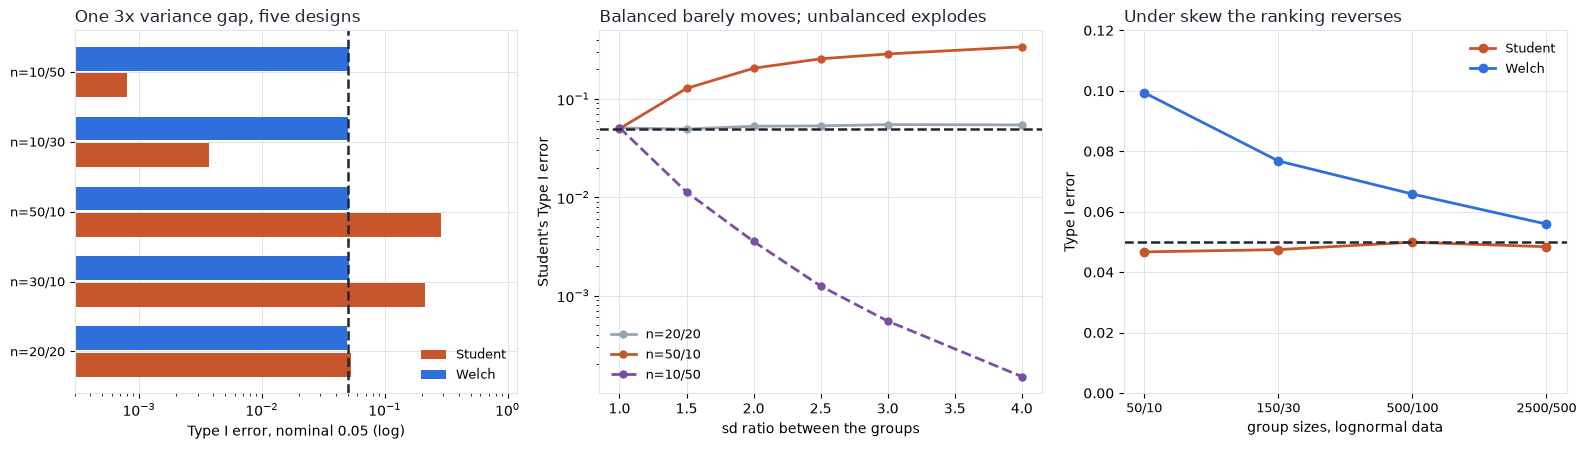

In [7]:
import matplotlib.pyplot as plt

INK, GRID, BG = "#1f2733", "#dfe4ea", "#ffffff"
STUDENT, WELCH, THIRD, FLAT = "#c8562b", "#2f6fdb", "#7a4fa3", "#9aa4b0"
R = 20_000

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), facecolor=BG)
for ax in axes:
    ax.set_facecolor(BG)
    ax.grid(True, color=GRID, lw=0.7)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(GRID)

ax = axes[0]
ds = [(20, 20), (30, 10), (50, 10), (10, 30), (10, 50)]
st = [simulate(a, b, sd2=3.0, reps=R, seed=40 + k)["student"] for k, (a, b) in enumerate(ds)]
we = [simulate(a, b, sd2=3.0, reps=R, seed=40 + k)["welch"] for k, (a, b) in enumerate(ds)]
y = np.arange(len(ds))
ax.barh(y - 0.19, st, height=0.34, color=STUDENT, label="Student")
ax.barh(y + 0.19, we, height=0.34, color=WELCH, label="Welch")
ax.axvline(ALPHA, color=INK, ls="--", lw=1.8)
ax.set_xscale("log")
ax.set_xlim(3e-4, 1.2)
ax.set_yticks(y)
ax.set_yticklabels([f"n={a}/{b}" for a, b in ds], fontsize=9)
ax.set_xlabel("Type I error, nominal 0.05 (log)")
ax.set_title("One 3x variance gap, five designs", color=INK, loc="left")
ax.legend(frameon=False, fontsize=9, loc="lower right")

ax = axes[1]
ratios = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 4.0])
for (n1, n2), col, style in [((20, 20), FLAT, "o-"), ((50, 10), STUDENT, "o-"),
                             ((10, 50), THIRD, "o--")]:
    ax.plot(ratios, [simulate(n1, n2, sd2=r, reps=R, seed=80 + j)["student"]
                     for j, r in enumerate(ratios)], style, color=col, lw=2, ms=5,
            label=f"n={n1}/{n2}")
ax.axhline(ALPHA, color=INK, ls="--", lw=1.8)
ax.set_yscale("log")
ax.set_xlabel("sd ratio between the groups")
ax.set_ylabel("Student's Type I error")
ax.set_title("Balanced barely moves; unbalanced explodes", color=INK, loc="left")
ax.legend(frameon=False, fontsize=9)

ax = axes[2]
pairs = [(50, 10), (150, 30), (500, 100), (2500, 500)]
runs = [simulate(a, b, dist="lognormal", reps=R, seed=160 + k) for k, (a, b) in enumerate(pairs)]
xs = np.arange(len(pairs))
ax.plot(xs, [r["student"] for r in runs], "o-", color=STUDENT, lw=2, ms=6, label="Student")
ax.plot(xs, [r["welch"] for r in runs], "o-", color=WELCH, lw=2, ms=6, label="Welch")
ax.axhline(ALPHA, color=INK, ls="--", lw=1.8)
ax.set_xticks(xs)
ax.set_xticklabels([f"{a}/{b}" for a, b in pairs], fontsize=9)
ax.set_ylim(0, 0.12)
ax.set_xlabel("group sizes, lognormal data")
ax.set_ylabel("Type I error")
ax.set_title("Under skew the ranking reverses", color=INK, loc="left")
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig("notebook_figure.png", dpi=120, facecolor=BG)
plt.show()

## Summary

| Claim you have probably heard | What the simulation measures |
|---|---|
| "A t-test is a t-test" | Student's 0.29 vs Welch's 0.05 on the same design, same null |
| "Check whether the variances are equal" | Half the condition. A 3x gap on a balanced design is harmless |
| "Unequal variance inflates your false positives" | Only if the *small* group has the large variance. Reversed, Student's drops to 0.0008 and has no power left |
| "Welch is more conservative, so it costs power" | Under 0.002 on balanced designs. But ~0.05 on unbalanced equal-variance ones, which is the real premium |
| "Just use a z-test, n is big enough" | Above nominal in all 15 cells, up to 0.081 |
| "Welch is the robust one" | Not to skew. On a lognormal with n=50/10 it runs at 0.095 while Student's holds at 0.051 |

**The rule that survives all of it:** default to Welch, and check group *balance* rather than
group variance. When the data is skewed and the groups are unequal, neither t-test is the answer -
bootstrap, or transform, and measure the result the way this notebook does.

## 8. Try your own design

Change the numbers and re-run. The null is exactly true in every case, so anything the tests
reject is a false positive you would have published.

In [8]:
# --- your design here -------------------------------------------------------
MY_N1, MY_N2 = 120, 18        # the group sizes you actually have
MY_SD1, MY_SD2 = 1.0, 2.5     # the spread you expect in each
MY_SHAPE = "normal"           # "normal" | "lognormal" | "t3" | "uniform"
MY_ALPHA = 0.05
# ----------------------------------------------------------------------------

r = simulate(MY_N1, MY_N2, MY_SD1, MY_SD2, MY_SHAPE, reps=40_000, alpha=MY_ALPHA, seed=2024)
print(f"n={MY_N1}/{MY_N2}, sd={MY_SD1}/{MY_SD2}, {MY_SHAPE}, alpha={MY_ALPHA}\n")
for name in ("student", "welch", "z-shortcut"):
    mult = r[name] / MY_ALPHA
    tag = "ok" if abs(mult - 1) <= 0.15 else ("INFLATED" if mult > 1 else "conservative")
    print(f"  {name:<12} {r[name]:.4f}   {mult:>5.2f}x nominal   {tag}")

print()
best = min(("student", "welch"), key=lambda t: abs(r[t] - MY_ALPHA))
print(f"On this design the honest choice between the two t-tests is: {best}")
if MY_SHAPE == "lognormal" and MY_N1 != MY_N2:
    print("...but the data is skewed and the groups are unequal, so bootstrap instead.")

# Want the power instead of the error rate? Set a true difference:
# r = simulate(MY_N1, MY_N2, MY_SD1, MY_SD2, MY_SHAPE, shift=0.5, reps=40_000, seed=7)

n=120/18, sd=1.0/2.5, normal, alpha=0.05

  student      0.2816    5.63x nominal   INFLATED
  welch        0.0514    1.03x nominal   ok
  z-shortcut   0.0662    1.32x nominal   INFLATED

On this design the honest choice between the two t-tests is: welch


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/t-test-variants)

The same study runs as a Streamlit app where you can drag the design around instead of editing
constants:

```bash
pip install -r requirements.txt
streamlit run app.py
```

`evidence.py` regenerates every number quoted here into `evidence.txt` and `results.json`, and
`pytest` asserts the findings so a library change that breaks one of them fails the suite.